In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [3]:
input_path = '../../input/서울의대법의학교실_Ancestry SNP Panel Genotype raw data'
regions = ['NEA', 'SEA', 'SWA']
popls = [
    'CHS', 'CHB', 'CDX', 'JPT', 'KOR', 
    'KHV', 'VNK', 'MYA',
    'BEB', 'ITU', 'GIH', 'STU', 'NP', 'IN', 'PJL', 'PT'
]
df = pd.read_csv(f'{input_path}/서울의대 법의학교실 Ancestry SNP genotype (2023-02-10).csv').dropna(how='all')
df = df.fillna('NN')
df = pd.concat([
        df, 
        df['SNU-ID'].str.split('-').apply(lambda x:x[1]).rename('popl')
    ], axis=1).astype('string')
df = df.sort_values(by='popl', key=lambda ser:ser.map(lambda x: popls.index(x)))
df = df.reset_index(drop=True)

In [4]:
from sklearn.impute import KNNImputer, SimpleImputer

genes = [el for el in df.columns if el.startswith('rs')]
df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer(n_neighbors=5)
X = imputer.fit_transform(df_chs)

In [5]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import LabelEncoder

dist_mat = pairwise_distances(X, metric='manhattan') / 2

region_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['region']), prepend=-1, append=-1) != 0)[0]
popl_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['popl']), prepend=-1, append=-1) != 0)[0]
# region_bdry = np.cumsum(np.fromiter(((df['region'] == region).sum() for region in [''] + regions), dtype=np.int32))
# popl_bdry = np.cumsum(np.fromiter(((df['popl'] == popl).sum() for popl in [''] + popls), dtype=np.int32))
region_center = (region_bdry[1:] + region_bdry[:-1])/2 + 0.5
popl_center = (popl_bdry[1:] + popl_bdry[:-1])/2

Fussy c-means

In [6]:
from pyclustering.cluster.fcm import fcm
from matplotlib.colors import to_rgb

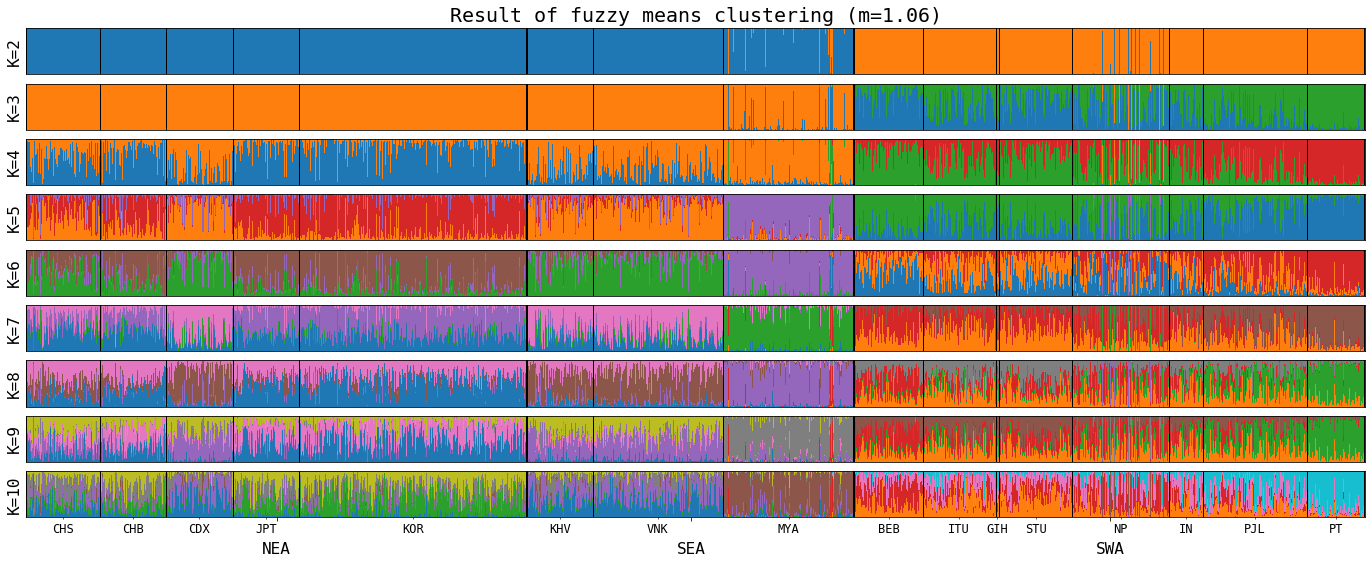

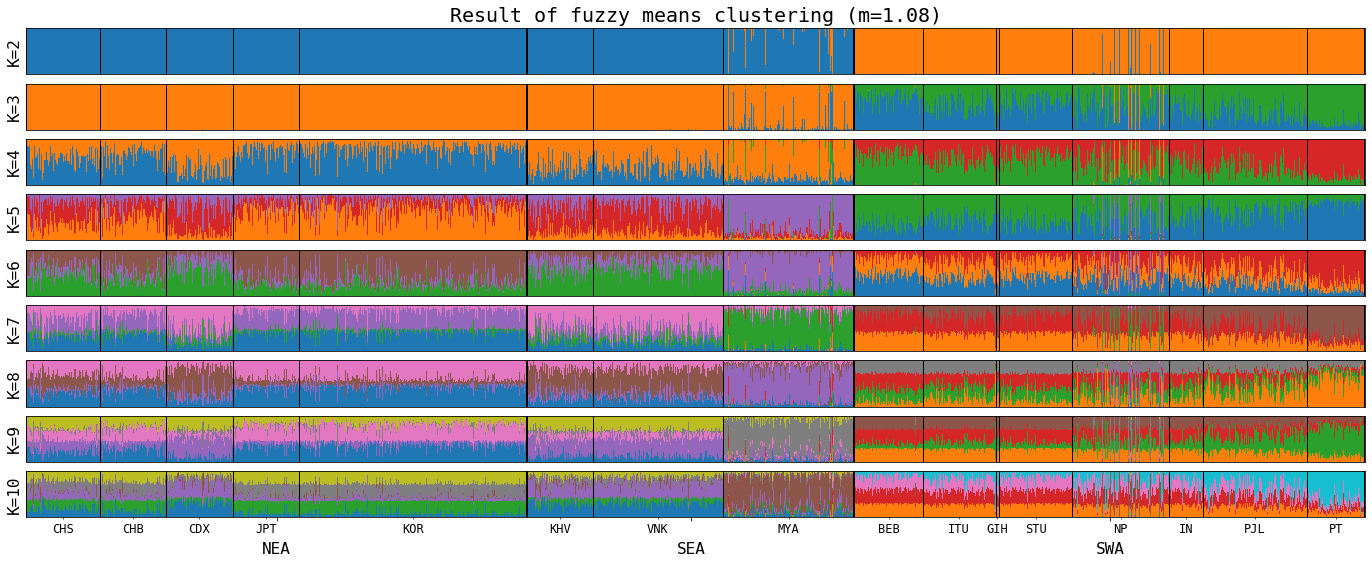

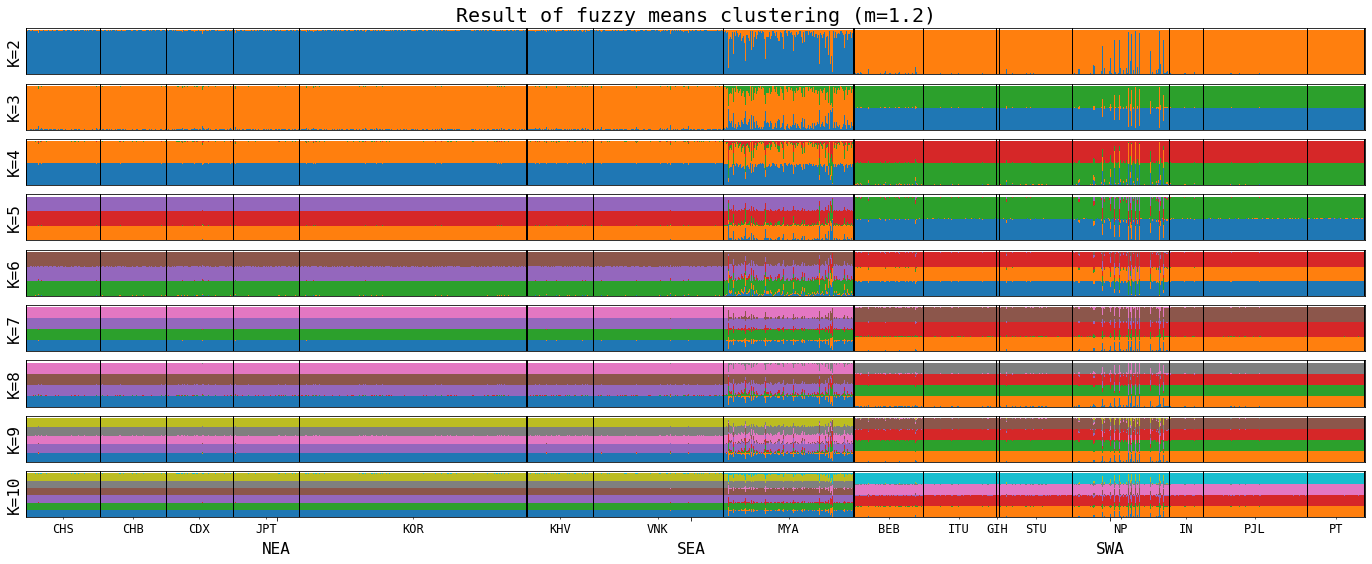

In [7]:
for m in (1.06, 1.08, 1.2):
    k_min, k_max = 2, 10

    fig, axs = plt.subplots(nrows=k_max-k_min+1, figsize=(24, k_max-k_min+1))
    for k in range(k_min, k_max+1):
        ax = axs[k-k_min]

        clusterer = fcm(data=X, initial_centers=np.random.default_rng(42).choice(X, k, replace=False, axis=0), m=m)
        clusterer.process()
        membership = clusterer.get_membership()
        ms_bar = np.array(membership)
        ms_bar = np.concatenate([np.zeros((X.shape[0], 1)), np.cumsum(ms_bar, axis=1)], axis=1)
        for i in range(k):
            ax.bar(np.arange(X.shape[0]), ms_bar[:, i+1]-ms_bar[:, i], width=1, bottom=ms_bar[:, i])
        
        ax.set_xlim(0, X.shape[0])
        for i in popl_bdry:
            ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=1)
        for i in region_bdry:
            ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=2)
        ax.set_ylabel(f'K={k}', fontsize=16)
        if k == k_min:
            ax.set_title(f'Result of fuzzy means clustering (m={m})', fontsize=20)
        if k < k_max:
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.set_xticks(region_center); ax.set_yticks([])
            ax.set_xticklabels(['\n' + el for el in regions], fontsize=16)
            ax.set_xticks(popl_center, minor=True)
            ax.set_xticklabels(popls, fontsize=12, minor=True)
    plt.show(); plt.close()

In [8]:
m=1.08
k=2
clusterer = fcm(data=X, initial_centers=np.random.default_rng(42).choice(X, k, replace=False, axis=0), m=m)
clusterer.process()
membership = clusterer.get_membership()
membership=np.array(membership)

Ball Mapper

In [9]:
import networkx as nx
from matplotlib import pyplot as plt
from pyballmapper import BallMapper

In [10]:
bm = BallMapper(membership, # the pointcloud, as a numpy array
                eps= 0.2)            # the radius of the balls

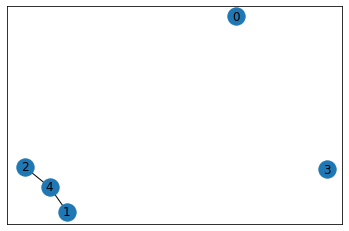

In [11]:
nx.draw_networkx(bm.Graph, 
                 pos=nx.spring_layout(bm.Graph, seed=24))

Regions

In [12]:
g=bm.Graph

In [13]:
labels=df['region']
save_loc = './ex/'

In [14]:
from matplotlib import cm

In [15]:
pyvis_available = True
from pyvis.network import Network
nt = Network(notebook=True, height="550px", width="100%",heading='region'+str(k))
nt.toggle_physics(True)

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [16]:
def node2compactrep(graph,node):
    interval_idx = graph.nodes[node]['points covered']
    s = f'Interval: {interval_idx}'
    return s

In [17]:
s=np.zeros(len(g.nodes))
for node in g.nodes:
    s[node]=len(g.nodes[node]['points covered'])/10

In [18]:
def save_piechart(graph,n):
    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw=dict(aspect="equal"))
    c = cm.get_cmap('tab10', 10)
    colors = [c(i) for i in range(10)]
    curr = labels[graph.nodes[n]['points covered']]
    counts = [curr[curr == i].shape[0] for i in regions]
    ax.pie(counts, colors=colors)
    plt.savefig(save_loc  + str(n) + '.png', dpi=30)
    plt.close(fig)
    return str(n) + '.png'

In [20]:
for node in g.nodes:
    nt.add_node(node, label='', title=str(node2compactrep(g,node)), shape='image', image=save_piechart(g,node), size=s[node])
for e in g.edges:
    n1, n2 = e[0], e[1]
    nt.add_edge(n1, n2)
nt.prep_notebook()
nt.show(save_loc+'region'+str(k)+'.html')

Popl

In [21]:
g=bm.Graph

In [22]:
labels=df['popl']
save_loc = './ex/'

In [23]:
from matplotlib import cm

In [24]:
pyvis_available = True
from pyvis.network import Network
nt = Network(notebook=True, height="550px", width="100%",heading='popl'+str(k))
nt.toggle_physics(True)

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


In [25]:
def node2compactrep(graph,node):
    interval_idx = graph.nodes[node]['points covered']
    s = f'Interval: {interval_idx}'
    return s

In [26]:
s=np.zeros(len(g.nodes))
for node in g.nodes:
    s[node]=len(g.nodes[node]['points covered'])/5

In [27]:
def save_piechart(graph,n):
    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw=dict(aspect="equal"))
    c = cm.get_cmap('rainbow', 16)
    colors = [c(i) for i in range(16)]
    curr = labels[graph.nodes[n]['points covered']]
    counts = [curr[curr == i].shape[0] for i in popls]
    ax.pie(counts, colors=colors)
    plt.savefig(save_loc  + str(n) + '.png', dpi=30)
    plt.close(fig)
    return str(n) + '.png'

In [28]:
for node in g.nodes:
    nt.add_node(node, label='', title=str(node2compactrep(g,node)), shape='image', image=save_piechart(g,node), size=s[node])
for e in g.edges:
    n1, n2 = e[0], e[1]
    nt.add_edge(n1, n2)
nt.prep_notebook()
nt.show(save_loc+'popl'+str(k)+'.html')

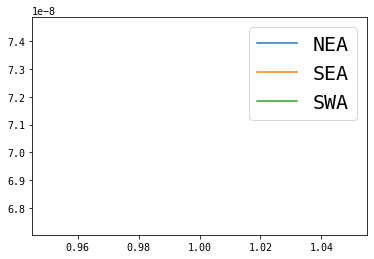

In [29]:
c = cm.get_cmap('tab10', 10)
plt.plot(membership[0,0],membership[0,1], color=c(0), markersize=2, label=regions[0])
plt.plot(membership[0,0],membership[0,1], color=c(1), markersize=2, label=regions[1])
plt.plot(membership[0,0],membership[0,1], color=c(2), markersize=2, label=regions[2])
plt.legend(fontsize=20)
plt.show()


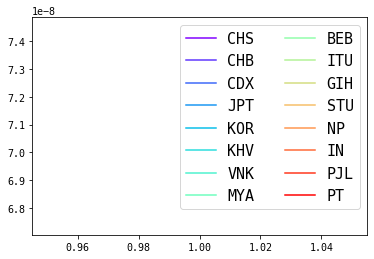

In [30]:
c = cm.get_cmap('rainbow', 16)
for i in range(16):
    plt.plot(membership[0,0],membership[0,1], color=c(i), markersize=2, label=popls[i])
plt.legend(ncol=2,fontsize=15)
plt.show()


In [31]:
df.loc[(df['popl']=='MYA')].index

Int64Index([1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069,
            ...
            1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257, 1258],
           dtype='int64', length=199)

In [32]:
df.loc[(df['popl']=='CDX')].index

Int64Index([212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
            ...
            304, 305, 306, 307, 308, 309, 310, 311, 312, 313],
           dtype='int64', length=102)